In [1]:
pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121

Looking in indexes: https://download.pytorch.org/whl/cu121
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import os, math, warnings, gc, random
import numpy as np, pandas as pd
import torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler, KBinsDiscretizer, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, f1_score, precision_score,
                             recall_score, confusion_matrix, classification_report,
                             ConfusionMatrixDisplay)
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')

SEED = 42
def seed_everything(seed=42):
    random.seed(seed); os.environ["PYTHONHASHSEED"] = str(seed)
    np.random.seed(seed); torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True; torch.backends.cudnn.benchmark = False
seed_everything(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', DEVICE)

Device: cuda


In [3]:
DATA_PATH = r"C:\Users\ADMIN\Desktop\Dữ Liệu\IDS2018-v2\NF-CSE-CIC-IDS2018-V2.parquet"
LABEL_COL   = 'Label'
N_PCA       = 20
N_BINS      = 32
BATCH_SIZE  = 1024
NUM_WORKERS = 0  

EPOCHS       = 2
WARMUP_EPOCHS= 3
LR           = 2e-3
MIN_LR       = 1e-5
WEIGHT_DECAY = 5e-4
LABEL_SMOOTH = 0.05
FOCAL_GAMMA  = 2.0
GRAD_CLIP    = 1.0
EMA_DECAY    = 0.999
PATIENCE     = 8          

D_MODEL     = 128
N_HEADS     = 8
N_PERSIST   = 8
LMM_HIDDEN  = 256
N_BLOCKS    = 3           
LMM_LAYERS  = 3           
SWA_WINDOW  = 32
DROPOUT     = 0.15

R_Q = 2
R_K = 2
R_V = 2

OUTLIER_TH  = 3.0
PRE_BATCH   = 50000

## 1. Load parquet + xử lý cột constant & log transform

In [4]:
df = pd.read_parquet(DATA_PATH)

std_series = df.std(numeric_only=True)
const_cols = std_series[std_series == 0].index.tolist()

if 'SRC_TO_DST_SECOND_BYTES' in df.columns:
    df['SRC_TO_DST_SECOND_BYTES_LOG'] = np.log1p(df['SRC_TO_DST_SECOND_BYTES'])
    df = df.drop(columns=['SRC_TO_DST_SECOND_BYTES'])


LABEL_MULTI = 'Attack' if 'Attack' in df.columns else 'Label'

drop_cols = [c for c in ['Label', 'Attack'] + const_cols if c in df.columns]
numerical_columns = [c for c in df.columns
                     if c not in drop_cols and np.issubdtype(df[c].dtype, np.number)]

X = df[numerical_columns].copy()
attack_raw = df[LABEL_MULTI].astype(str).fillna('Benign').values
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(attack_raw).astype(np.int64)
CLASS_NAMES = list(label_encoder.classes_)

## 2. Split train / val / test (stratified)

In [5]:
X_tr, X_tmp, y_tr, y_tmp = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=SEED)
X_val, X_te, y_val, y_te = train_test_split(
    X_tmp, y_tmp, test_size=2/3, stratify=y_tmp, random_state=SEED)
del X, X_tmp, y_tmp, df; gc.collect()

20

## 3. Robust preprocessing theo batch (NaN / Inf / Outlier)

In [6]:
def robust_preprocess_large_data(X_train, X_val, X_test,
                                  batch_size=50000, outlier_threshold=3.0):
    if hasattr(X_train, 'values'): X_train = X_train.values
    if hasattr(X_val, 'values'):   X_val   = X_val.values
    if hasattr(X_test, 'values'):  X_test  = X_test.values
    X_train = X_train.astype(np.float32)
    X_val   = X_val.astype(np.float32)
    X_test  = X_test.astype(np.float32)

    sample_size = min(100000, len(X_train))
    idx = np.random.choice(len(X_train), sample_size, replace=False)
    X_sample = X_train[idx].copy()
    medians = np.nanmedian(X_sample, axis=0)
    stds    = np.nanstd(X_sample, axis=0)
    stds[stds == 0] = 1.0

    def process(batch):
        batch = batch.copy()
        batch[np.isinf(batch)] = np.nan
        for col in range(batch.shape[1]):
            cd = batch[:, col]; med = medians[col]; sd = stds[col]
            z = np.abs((cd - med) / sd)
            mask = z > outlier_threshold
            if mask.any(): batch[mask, col] = med
            nan_mask = np.isnan(batch[:, col])
            if nan_mask.any(): batch[nan_mask, col] = med
        return np.clip(batch, -1e6, 1e6)

    def by_batch(arr, name):
        n = len(arr); nb = int(np.ceil(n / batch_size)); out = []
        for i in range(nb):
            s, e = i*batch_size, min((i+1)*batch_size, n)
            out.append(process(arr[s:e]))
            if (i+1) % 20 == 0 or (i+1) == nb:
                print(f'  {name}: {e:,}/{n:,}')
        return np.vstack(out)

    Xtr = by_batch(X_train, 'train')
    Xva = by_batch(X_val,   'val  ')
    Xte = by_batch(X_test,  'test ')
    return Xtr, Xva, Xte

X_tr_p, X_val_p, X_te_p = robust_preprocess_large_data(
    X_tr, X_val, X_te, batch_size=PRE_BATCH, outlier_threshold=OUTLIER_TH)
del X_tr, X_val, X_te; gc.collect()

  train: 1,000,000/11,990,800
  train: 2,000,000/11,990,800
  train: 3,000,000/11,990,800
  train: 4,000,000/11,990,800
  train: 5,000,000/11,990,800
  train: 6,000,000/11,990,800
  train: 7,000,000/11,990,800
  train: 8,000,000/11,990,800
  train: 9,000,000/11,990,800
  train: 10,000,000/11,990,800
  train: 11,000,000/11,990,800
  train: 11,990,800/11,990,800
  val  : 1,000,000/1,712,971
  val  : 1,712,971/1,712,971
  test : 1,000,000/3,425,944
  test : 2,000,000/3,425,944
  test : 3,000,000/3,425,944
  test : 3,425,944/3,425,944


0

## 4. PCA giảm chiều (40 → 20)

In [7]:
pca = PCA(n_components=N_PCA, random_state=SEED)
X_tr_pca  = pca.fit_transform(X_tr_p)
X_val_pca = pca.transform(X_val_p)
X_te_pca  = pca.transform(X_te_p)

evr = pca.explained_variance_ratio_
del X_tr_p, X_val_p, X_te_p; gc.collect()

0

## 5. StandardScaler + Tokenize bằng KBinsDiscretizer

In [8]:
scaler = StandardScaler()
X_tr_sc  = scaler.fit_transform(X_tr_pca)
X_val_sc = scaler.transform(X_val_pca)
X_te_sc  = scaler.transform(X_te_pca)

kbd = KBinsDiscretizer(n_bins=N_BINS, encode='ordinal', strategy='quantile')
tok_tr  = kbd.fit_transform(X_tr_sc).astype(np.int64)
tok_val = kbd.transform(X_val_sc).astype(np.int64)
tok_te  = kbd.transform(X_te_sc).astype(np.int64)

ordered_vocab = [int(max(tok_tr[:, i].max(), tok_val[:, i].max(), tok_te[:, i].max())) + 2
                 for i in range(tok_tr.shape[1])]
SEQ_LEN_FINAL = tok_tr.shape[1]
N_CLASSES = len(np.unique(y_tr))


## 6. Dataset & DataLoader

In [9]:
class TokenDS(Dataset):
    def __init__(self, X_tok, y):
        self.X = torch.from_numpy(X_tok).long()
        self.y = torch.from_numpy(y).long()
    def __len__(self): return len(self.y)
    def __getitem__(self, i): return self.X[i], self.y[i]

train_ds = TokenDS(tok_tr,  y_tr)
val_ds   = TokenDS(tok_val, y_val)
test_ds  = TokenDS(tok_te,  y_te)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  drop_last=True,
                          num_workers=NUM_WORKERS, pin_memory=(NUM_WORKERS > 0), persistent_workers=(NUM_WORKERS > 0))
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=(NUM_WORKERS > 0), persistent_workers=(NUM_WORKERS > 0))
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=(NUM_WORKERS > 0), persistent_workers=(NUM_WORKERS > 0))

## 7. Kiến trúc Titan MAG

In [10]:
class Adaptive_Weighting_Attention(nn.Module):
    def __init__(self, d_model, n_heads, d_head, R):
        super().__init__()

        assert R >= 1 and n_heads >= 1 and d_head >= 1

        self.R  = R
        self.h  = n_heads
        self.dh = d_head

        self.A = nn.Linear(d_model, R * n_heads, bias=False)
        self.B = nn.Linear(d_model, R * d_head,  bias=False)

        nn.init.xavier_uniform_(self.A.weight)
        nn.init.xavier_uniform_(self.B.weight)

        self.alpha = nn.Parameter(torch.ones(R, n_heads))

    def forward(self, x):                       
        B, L, _ = x.shape

        a = self.A(x).view(B, L, self.R, self.h)    
        b = self.B(x).view(B, L, self.R, self.dh)   

        a = a * self.alpha.view(1, 1, self.R, self.h)

        out = torch.einsum('blrh,blrd->blhd', a, b) / float(self.R)

        return out                                   


class FeatureEmbedding(nn.Module):
    def __init__(self, vocab_sizes, d_model, max_len=512, dropout=0.1):
        super().__init__()
        self.embs = nn.ModuleList([nn.Embedding(v, d_model) for v in vocab_sizes])
        self.pos  = nn.Parameter(torch.randn(1, max_len, d_model) * 0.02)
        self.norm = nn.LayerNorm(d_model)
        self.drop = nn.Dropout(dropout)
    def forward(self, x):
        B, L = x.shape
        out = torch.stack([self.embs[i](x[:, i]) for i in range(L)], dim=1)
        out = out + self.pos[:, :L]
        return self.drop(self.norm(out))


class DimReduceBlock(nn.Module):
    def __init__(self, d_model, latent_dim=None, dropout=0.1):
        super().__init__()
        if latent_dim is None: latent_dim = d_model // 2
        self.encoder = nn.Sequential(nn.Linear(d_model, latent_dim), nn.GELU(), nn.Dropout(dropout))
        self.decoder = nn.Sequential(nn.Linear(latent_dim, d_model), nn.GELU(), nn.Dropout(dropout))
        self.norm    = nn.LayerNorm(d_model)
    def forward(self, x):
        return self.norm(x + self.decoder(self.encoder(x)))


class HiddenMLP(nn.Module):
    def __init__(self, d_model, expansion=4, dropout=0.1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d_model, d_model * expansion), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(d_model * expansion, d_model), nn.Dropout(dropout),
        )
        self.norm = nn.LayerNorm(d_model)
    def forward(self, x):
        return self.norm(x + self.net(x))


class NeuralLongTermMemory(nn.Module):
    def __init__(self, d_model, hidden=256, n_layers=3, dropout=0.1):
        super().__init__()
        layers = []
        in_dim = d_model
        for _ in range(n_layers - 1):
            layers += [nn.Linear(in_dim, hidden), nn.GELU(), nn.Dropout(dropout)]
            in_dim = hidden
        layers.append(nn.Linear(in_dim, d_model))
        self.M = nn.Sequential(*layers)

        self.key       = nn.Linear(d_model, d_model)
        self.value     = nn.Linear(d_model, d_model)
        self.query     = nn.Linear(d_model, d_model)
        self.alpha_net = nn.Linear(d_model, 1)
        self.eta_net   = nn.Linear(d_model, 1)
        self.theta_net = nn.Linear(d_model, 1)
        self.out_norm  = nn.LayerNorm(d_model)

    def forward(self, h):
        B, L, D = h.shape
        k = self.key(h); v = self.value(h); q = self.query(h)
        alpha = torch.sigmoid(self.alpha_net(h))
        eta   = torch.sigmoid(self.eta_net(h))
        theta = torch.sigmoid(self.theta_net(h)) * 0.1
        Mt = torch.zeros(B, D, device=h.device)
        St = torch.zeros(B, D, device=h.device)
        outs = []
        for t in range(L):
            kt, vt, qt = k[:, t], v[:, t], q[:, t]
            v_hat = self.M(kt) + Mt
            grad  = 2.0 * (v_hat - vt)
            St = eta[:, t] * St - theta[:, t] * grad
            Mt = (1 - alpha[:, t]) * Mt + St
            outs.append(self.M(qt) + Mt)
        return self.out_norm(torch.stack(outs, dim=1))


class TPASlidingWindowAttention(nn.Module):
    def __init__(self, d_model, n_heads, R_Q=2, R_K=2, R_V=2, window=32, dropout=0.1):
        super().__init__()
        assert d_model % n_heads == 0
        self.d, self.h = d_model, n_heads
        self.dh = d_model // n_heads
        self.q_proj = Adaptive_Weighting_Attention(d_model, n_heads, self.dh, R_Q)
        self.k_proj = Adaptive_Weighting_Attention(d_model, n_heads, self.dh, R_K)
        self.v_proj = Adaptive_Weighting_Attention(d_model, n_heads, self.dh, R_V)
        self.proj   = nn.Linear(d_model, d_model)
        self.norm   = nn.LayerNorm(d_model)
        self.drop   = nn.Dropout(dropout)
        self.window = window

    def _to_heads(self, t):     
        return t.permute(0, 2, 1, 3).contiguous()

    def forward(self, x):
        B, L, D = x.shape
        q = self._to_heads(self.q_proj(x))
        k = self._to_heads(self.k_proj(x))
        v = self._to_heads(self.v_proj(x))
        idx  = torch.arange(L, device=x.device)
        diff = idx.unsqueeze(0) - idx.unsqueeze(1)
        block = (diff > 0) | (diff < -(self.window - 1))
        attn_mask = torch.where(block,
                                torch.tensor(float('-inf'), device=x.device),
                                torch.tensor(0.0, device=x.device))
        y = F.scaled_dot_product_attention(q, k, v, attn_mask=attn_mask, is_causal=False)
        y = y.transpose(1, 2).contiguous().reshape(B, L, D)
        return self.norm(x + self.drop(self.proj(y)))


class TitanBlock(nn.Module):
    def __init__(self, d_model, n_heads, lmm_hidden, swa_window,
                 lmm_layers, R_Q, R_K, R_V, dropout=0.1):
        super().__init__()
        self.dim_reduce = DimReduceBlock(d_model, dropout=dropout)
        self.hidden_mlp = HiddenMLP(d_model, expansion=4, dropout=dropout)
        self.stm        = TPASlidingWindowAttention(d_model, n_heads,
                                                    R_Q, R_K, R_V,
                                                    window=swa_window, dropout=dropout)
        self.lmm        = NeuralLongTermMemory(d_model, hidden=lmm_hidden,
                                               n_layers=lmm_layers, dropout=dropout)
        self.combine    = nn.Linear(d_model * 2, d_model)
        self.gate_proj  = nn.Linear(d_model, d_model)
        self.gate_norm  = nn.LayerNorm(d_model)
        self.drop       = nn.Dropout(dropout)

    def forward(self, x):
        h = self.dim_reduce(x)
        h = self.hidden_mlp(h)
        y_swa = self.stm(h)
        y_lmm = self.lmm(h)
        merged = self.combine(torch.cat([y_swa, y_lmm], dim=-1))
        out = self.gate_norm(merged * torch.sigmoid(self.gate_proj(h)))
        return x + self.drop(out)


class TitanMAG(nn.Module):
    def __init__(self, vocab_sizes, n_classes, d_model=128, n_heads=8,
                 n_persist=8, lmm_hidden=256, swa_window=32, lmm_layers=3,
                 n_blocks=3, R_Q=2, R_K=2, R_V=2, dropout=0.15,
                 seq_len_max=512):
        super().__init__()
        self.embed      = FeatureEmbedding(vocab_sizes, d_model,
                                           max_len=seq_len_max, dropout=dropout)
        self.persistent = nn.Parameter(torch.randn(1, n_persist, d_model) * 0.02)
        self.blocks     = nn.ModuleList([
            TitanBlock(d_model, n_heads, lmm_hidden, swa_window,
                       lmm_layers, R_Q, R_K, R_V, dropout=dropout)
            for _ in range(n_blocks)
        ])
        self.n_persist = n_persist
        self.head = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Linear(d_model, d_model * 2), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(d_model * 2, d_model), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(d_model, n_classes),
        )

    def forward(self, x):
        B = x.size(0)
        h = self.embed(x)
        persist = self.persistent.expand(B, -1, -1)
        h = torch.cat([persist, h], dim=1)
        for blk in self.blocks:
            h = blk(h)
        h = h[:, self.n_persist:]
        pooled = h.mean(dim=1)
        return self.head(pooled)


model = TitanMAG(ordered_vocab, N_CLASSES,
                 d_model=D_MODEL, n_heads=N_HEADS,
                 n_persist=N_PERSIST, lmm_hidden=LMM_HIDDEN,
                 swa_window=SWA_WINDOW, lmm_layers=LMM_LAYERS,
                 n_blocks=N_BLOCKS,
                 R_Q=R_Q, R_K=R_K, R_V=R_V,
                 dropout=DROPOUT,
                 seq_len_max=SEQ_LEN_FINAL + N_PERSIST).to(DEVICE)

awa_alphas = [(n, p.shape) for n, p in model.named_parameters() if 'alpha' in n and 'net' not in n]



## 8. Train

In [11]:
import copy as _copy

class FocalLoss(nn.Module):
    def __init__(self, class_weights=None, gamma=2.0, label_smoothing=0.0):
        super().__init__()
        self.gamma = gamma
        self.ls    = label_smoothing
        self.register_buffer('w', class_weights if class_weights is not None else torch.tensor([]))
    def forward(self, logits, target):
        w = self.w if self.w.numel() > 0 else None
        ce = F.cross_entropy(logits, target, weight=w,
                             label_smoothing=self.ls, reduction='none')
        pt = torch.exp(-ce)
        return ((1 - pt) ** self.gamma * ce).mean()

_cnt = np.bincount(y_tr, minlength=N_CLASSES).astype(np.float64)
_cnt[_cnt == 0] = 1.0
_w   = _cnt.sum() / (N_CLASSES * _cnt)
_w   = np.clip(_w / _w.mean(), 0.25, 10.0)
class_weights = torch.tensor(_w, dtype=torch.float32, device=DEVICE)

criterion = FocalLoss(class_weights=class_weights,
                      gamma=FOCAL_GAMMA, label_smoothing=LABEL_SMOOTH).to(DEVICE)

optimizer = torch.optim.AdamW(model.parameters(), lr=LR,
                              weight_decay=WEIGHT_DECAY, betas=(0.9, 0.999))

steps_per_epoch = max(1, len(train_loader))
total_steps     = EPOCHS * steps_per_epoch
warmup_steps    = WARMUP_EPOCHS * steps_per_epoch

def lr_lambda(step):
    if step < warmup_steps:
        return (step + 1) / max(1, warmup_steps)
    prog = (step - warmup_steps) / max(1, total_steps - warmup_steps)
    return max(MIN_LR / LR, 0.5 * (1 + math.cos(math.pi * prog)))

scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

class EMA:
    def __init__(self, model, decay=0.999):
        self.decay = decay
        self.shadow = {k: v.detach().clone() for k, v in model.state_dict().items()
                       if v.dtype.is_floating_point}
    @torch.no_grad()
    def update(self, model):
        for k, v in model.state_dict().items():
            if k in self.shadow:
                self.shadow[k].mul_(self.decay).add_(v.detach(), alpha=1 - self.decay)
    def apply_to(self, model):
        self.backup = {k: v.detach().clone() for k, v in model.state_dict().items()
                       if k in self.shadow}
        sd = model.state_dict()
        for k in self.shadow: sd[k].copy_(self.shadow[k])
    def restore(self, model):
        sd = model.state_dict()
        for k, v in self.backup.items(): sd[k].copy_(v)
        self.backup = {}

ema = EMA(model, decay=EMA_DECAY)

def evaluate(model, loader):
    model.eval(); all_p, all_t = [], []
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(DEVICE)
            all_p.append(model(xb).argmax(-1).cpu().numpy())
            all_t.append(yb.numpy())
    p = np.concatenate(all_p); t = np.concatenate(all_t)
    return {
        'acc':     accuracy_score(t, p),
        'f1':      f1_score(t, p, average='weighted', zero_division=0),
        'f1_macro':f1_score(t, p, average='macro',    zero_division=0),
        'prec':    precision_score(t, p, average='weighted', zero_division=0),
        'rec':     recall_score(t, p, average='weighted',    zero_division=0),
        'pred': p, 'true': t,
    }

history = []
best_f1 = -1.0
best_state = None
patience_left = PATIENCE

for epoch in range(1, EPOCHS + 1):
    model.train(); losses = []
    for xb, yb in train_loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
        optimizer.step()
        scheduler.step()
        ema.update(model)
        losses.append(loss.item())

    ema.apply_to(model)
    m = evaluate(model, val_loader)
    ema.restore(model)

    history.append({'epoch': epoch, 'loss': float(np.mean(losses)),
                    **{k: m[k] for k in ['acc','f1','f1_macro','prec','rec']}})
    cur_lr = optimizer.param_groups[0]['lr']
    print(f'[Epoch {epoch:2d}/{EPOCHS}] lr={cur_lr:.2e} | loss={np.mean(losses):.4f} | acc={m["acc"]:.4f} | f1={m["f1"]:.4f} | prec={m["prec"]:.4f} | rec={m["rec"]:.4f}.')


    if m['f1_macro'] > best_f1 + 1e-4:
        best_f1 = m['f1_macro']
        ema.apply_to(model)
        best_state = _copy.deepcopy(model.state_dict())
        ema.restore(model)
        patience_left = PATIENCE
    else:
        patience_left -= 1
        if patience_left <= 0:
            print(f' Early stopping tại epoch {epoch} (best macro-F1={best_f1:.4f})')
            break

if best_state is not None:
    model.load_state_dict(best_state)

[Epoch  1/2] lr=6.67e-04 | loss=0.0210 | acc=0.9936 | f1=0.9921 | prec=0.9929 | rec=0.9936.
[Epoch  2/2] lr=1.33e-03 | loss=0.0152 | acc=0.9938 | f1=0.9922 | prec=0.9936 | rec=0.9938.


## 9. Đánh giá trên tập TEST + Confusion Matrix


===== FINAL TEST METRICS (Multi-class) =====
Accuracy        : 0.9938
F1 (weighted)   : 0.9922
F1 (macro)      : 0.7663
Precision (w)   : 0.9936
Recall (w)      : 0.9938

----- Classification Report -----
                          precision    recall  f1-score   support

                  Benign     0.9941    0.9995    0.9968   3020338
                     Bot     0.9957    0.9973    0.9965      5607
        Brute Force -Web     0.8511    0.0932    0.1681       429
        Brute Force -XSS     0.4265    0.1568    0.2292       185
        DDOS attack-HOIC     0.9965    1.0000    0.9982    213376
    DDOS attack-LOIC-UDP     0.8485    0.9692    0.9049       422
  DDoS attacks-LOIC-HTTP     0.9936    0.9997    0.9966     41415
   DoS attacks-GoldenEye     0.8954    0.8613    0.8780      5545
        DoS attacks-Hulk     0.9895    0.9935    0.9915     86529
DoS attacks-SlowHTTPTest     0.9951    1.0000    0.9975      2823
   DoS attacks-Slowloris     0.8714    0.9863    0.9253      1903
 

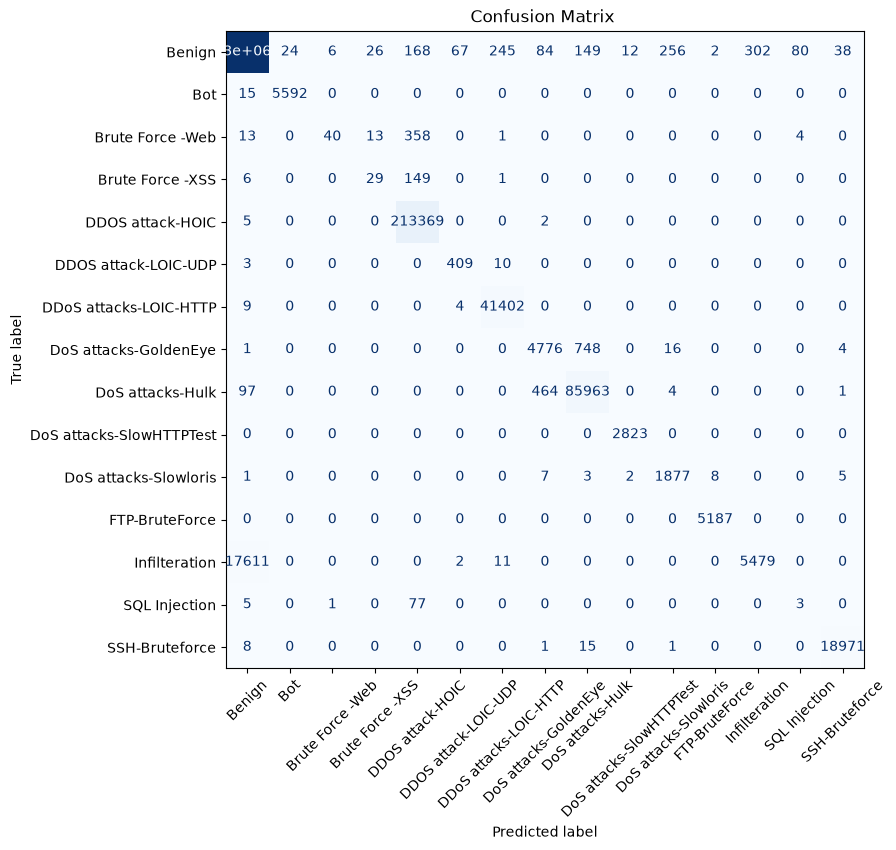

In [12]:
m = evaluate(model, test_loader)
print('\n===== FINAL TEST METRICS (Multi-class) =====')
print(f'Accuracy        : {m["acc"]:.4f}')
print(f'F1 (weighted)   : {m["f1"]:.4f}')
print(f'F1 (macro)      : {m["f1_macro"]:.4f}')
print(f'Precision (w)   : {m["prec"]:.4f}')
print(f'Recall (w)      : {m["rec"]:.4f}')

print('\n----- Classification Report -----')
print(classification_report(m['true'], m['pred'],
                            target_names=CLASS_NAMES, zero_division=0, digits=4))

labels_idx = list(range(len(CLASS_NAMES)))
cm = confusion_matrix(m['true'], m['pred'], labels=labels_idx)
size = max(6, len(CLASS_NAMES) * 0.6)
fig, ax = plt.subplots(figsize=(size, size))
ConfusionMatrixDisplay(cm, display_labels=CLASS_NAMES).plot(
    ax=ax, cmap='Blues', colorbar=False, xticks_rotation=45)
plt.title('Confusion Matrix ')
plt.tight_layout(); plt.show()